### Vision_1用的是PCA处理数据后的DNN，效果不佳，这个Vision_2用transformer来试试

### 还有K-fold划分数据集，SVM，好多办法来做。

In [21]:
import os
import glob
import numpy as np
import pandas as pd
import re

# 1. 读取 Excel 表格
csv_path = r"C:\Users\28439\Desktop\ASD\abide_data\ABIDE_pcp\Phenotypic_V1_0b_preprocessed1.csv"
phenotype_df = pd.read_csv(csv_path)

# 2. 找到所有的 .1D 脑区数据文件
folder_path = r'C:\Users\28439\Desktop\ASD\abide_data\ABIDE_pcp\cpac\nofilt_noglobal'
file_list = glob.glob(os.path.join(folder_path, '*.1D'))

# 3. 严格使用你原版的变量名
matched_all_time_series = []  # 最终会存放计算好的相关系数矩阵
matched_labels = []
nan_samples = []              # 用来记录包含 NaN 的样本索引

success_count = 0
fail_count = 0

for file_path in file_list:
    filename = os.path.basename(file_path)

    # 提取 SUB_ID
    match = re.search(r'\d{5,7}', filename)
    if not match:
        print(f"无法从文件名中提取数字 ID: {filename}")
        continue

    sub_id = int(match.group())

    # 去 Excel 查找对应行
    subject_row = phenotype_df[phenotype_df['SUB_ID'] == sub_id]

    if not subject_row.empty:
        # 读取原始时间序列
        time_series = np.loadtxt(file_path)

        # 加微弱噪声防死脑区（分母为0）
        noise = np.random.normal(0, 1e-5, size=time_series.shape)
        ts_fixed = time_series + noise

        # 直接在这里计算相关系数矩阵
        matrix = np.corrcoef(ts_fixed, rowvar=False)

        # 严格检查这个矩阵有没有 NaN
        if np.isnan(matrix).any():
            nan_samples.append(success_count)  # 记录当前样本在列表中的索引
            matrix = np.nan_to_num(matrix)     # 顺手把 NaN 填成 0 确保安全

        label = subject_row['DX_GROUP'].values[0]

        # 塞进你的原版列表里
        matched_all_time_series.append(matrix)
        matched_labels.append(label - 1)  # 1,2 变 0,1

        success_count += 1
    else:
        fail_count += 1

print(f"结束。成功: {success_count} 个，失败: {fail_count} 个。")
print(f"包含 NaN 的样本总数: {len(nan_samples)} / {len(matched_all_time_series)}")
if len(nan_samples) > 0:
    print(f"具体有问题的样本索引: {nan_samples}")

结束。成功: 871 个，失败: 0 个。
包含 NaN 的样本总数: 0 / 871


In [22]:
nan_samples = []
for i in range(len(matched_all_time_series)):
    if np.isnan(matched_all_time_series[i]).any():
        nan_samples.append(i)

print(f"包含 NaN 的样本总数: {len(nan_samples)} / {len(matched_all_time_series)}")
print(f"具体有问题的样本索引: {nan_samples}")

包含 NaN 的样本总数: 0 / 871
具体有问题的样本索引: []


### 前面导入处理数据的步骤一致

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
class BrainTransformer(nn.Module):
    def __init__(self, num_regions=116, input_dim=116, d_model=64, nhead=4, num_layers=2, num_classes=2):
        super(BrainTransformer, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.region_embedding = nn.Parameter(torch.randn(1, num_regions, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=0.3,
            activation='gelu',
            batch_first=True  # 确保输入维度是 (batch, seq, feature)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.layer_norm = nn.LayerNorm(d_model)
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(0.4), # 进一步防过拟合
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):

        x = self.input_projection(x)
        x = x + self.region_embedding
        # 送入 Transformer 提取全局脑区协同特征
        x = self.transformer_encoder(x) # 输出形状: (batch_size, 116, d_model)
        # 池化操作：对 116 个脑区特征取平均，压缩成整个大脑的全局表征
        x = x.mean(dim=1) # 输出形状: (batch_size, d_model)
        # 标准化与最终分类
        x = self.layer_norm(x)
        out = self.fc(x) # 输出形状: (batch_size, 2)

        return out

In [25]:
class BrainDataset(Dataset):
    def __init__(self, matrices, labels):
        self.matrices = torch.tensor(matrices, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.matrices[idx], self.labels[idx]

### 由于参数量太小，使用Kfold来增加参数和准确性。

In [26]:
X = np.array(matched_all_time_series, dtype=np.float32)  # (871, 116, 116)
y = np.array(matched_labels)

num_folds = 5
epochs = 30
patience = 10

skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

history = {
    'train_loss': np.full((num_folds, epochs), np.nan),
    'test_loss': np.full((num_folds, epochs), np.nan),
    'train_acc': np.full((num_folds, epochs), np.nan),
    'test_acc': np.full((num_folds, epochs), np.nan)
}

all_best_trues, all_best_preds, fold_accuracies = [], [], []

In [27]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- 正在训练第 {fold + 1} / {num_folds} 折 ---")

    X_train_fold = X[train_idx]
    X_test_fold = X[test_idx]

    train_loader = DataLoader(BrainDataset(X_train_fold, y[train_idx]), batch_size=32, shuffle=True)
    test_loader = DataLoader(BrainDataset(X_test_fold, y[test_idx]), batch_size=32, shuffle=False)

    model = BrainTransformer(num_regions=116, input_dim=116, d_model=64, nhead=4, num_layers=2).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_test_loss = float('inf')
    epochs_no_improve = 0
    fold_best_preds, fold_best_trues = [], []
    best_acc_for_fold = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for matrices, labels in train_loader:
            matrices, labels = matrices.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(matrices)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()

            train_loss += loss.item() * matrices.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total

        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        epoch_preds, epoch_trues = [], []

        with torch.no_grad():
            for matrices, labels in test_loader:
                matrices, labels = matrices.to(device), labels.to(device)
                outputs = model(matrices)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * matrices.size(0)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

                epoch_preds.extend(predicted.cpu().numpy())
                epoch_trues.extend(labels.cpu().numpy())

        epoch_test_loss = test_loss / test_total
        epoch_test_acc = test_correct / test_total

        history['train_loss'][fold, epoch] = epoch_train_loss
        history['test_loss'][fold, epoch] = epoch_test_loss
        history['train_acc'][fold, epoch] = epoch_train_acc
        history['test_acc'][fold, epoch] = epoch_test_acc

        scheduler.step(epoch_test_loss)

        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss
            best_acc_for_fold = epoch_test_acc
            fold_best_preds = epoch_preds
            fold_best_trues = epoch_trues
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc*100:.2f}%")

        if epochs_no_improve >= patience:
            print(f"🚀 触发早停机制，在 Epoch {epoch+1} 停止训练！")
            break

    print(f"第 {fold + 1} 折最优准确率: {best_acc_for_fold * 100:.2f}%")
    fold_accuracies.append(best_acc_for_fold)
    all_best_trues.extend(fold_best_trues)
    all_best_preds.extend(fold_best_preds)

print("\n" + "="*40)
print(f"五折平均准确率: {np.mean(fold_accuracies) * 100:.2f}%")


--- 正在训练第 1 / 5 折 ---
Epoch [05/30] | Train Loss: 0.6952 | Train Acc: 49.14% | Test Loss: 0.6900 | Test Acc: 53.71%
Epoch [10/30] | Train Loss: 0.6926 | Train Acc: 51.44% | Test Loss: 0.6899 | Test Acc: 53.71%
Epoch [15/30] | Train Loss: 0.6917 | Train Acc: 52.59% | Test Loss: 0.6897 | Test Acc: 53.71%
Epoch [20/30] | Train Loss: 0.6941 | Train Acc: 52.44% | Test Loss: 0.6897 | Test Acc: 53.71%
Epoch [25/30] | Train Loss: 0.6909 | Train Acc: 51.58% | Test Loss: 0.6896 | Test Acc: 53.71%
Epoch [30/30] | Train Loss: 0.6923 | Train Acc: 52.59% | Test Loss: 0.6896 | Test Acc: 53.71%
第 1 折最优准确率: 53.71%

--- 正在训练第 2 / 5 折 ---
Epoch [05/30] | Train Loss: 0.6903 | Train Acc: 53.52% | Test Loss: 0.6926 | Test Acc: 53.45%
Epoch [10/30] | Train Loss: 0.6877 | Train Acc: 56.24% | Test Loss: 0.6916 | Test Acc: 53.45%
Epoch [15/30] | Train Loss: 0.6842 | Train Acc: 53.52% | Test Loss: 0.6913 | Test Acc: 52.87%
Epoch [20/30] | Train Loss: 0.6826 | Train Acc: 55.38% | Test Loss: 0.6917 | Test Acc: 54

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

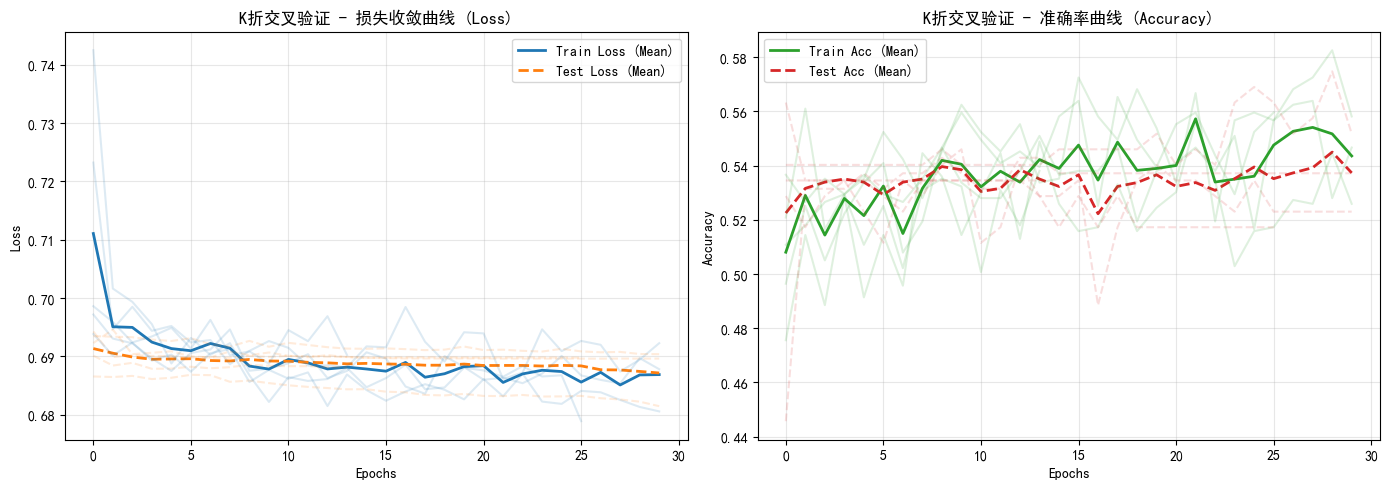

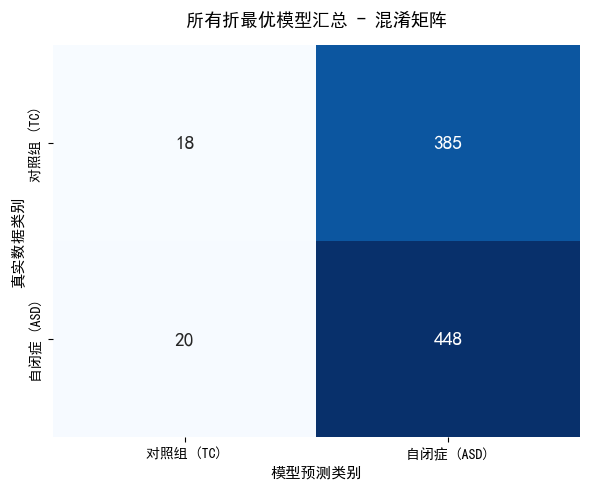

In [29]:

mean_train_loss = np.nanmean(history['train_loss'], axis=0)
mean_test_loss = np.nanmean(history['test_loss'], axis=0)
mean_train_acc = np.nanmean(history['train_acc'], axis=0)
mean_test_acc = np.nanmean(history['test_acc'], axis=0)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# 画出 5 折平均的 Loss 趋势
plt.plot(mean_train_loss, label='Train Loss (Mean)', color='#1f77b4', lw=2)
plt.plot(mean_test_loss, label='Test Loss (Mean)', color='#ff7f0e', lw=2, linestyle='--')

# 把每一折实际跑到的细线画出来
for f in range(num_folds):
    # 找到这一折实际跑了多少个 epoch（非 nan 的长度）
    valid_epochs = np.sum(~np.isnan(history['train_loss'][f]))
    plt.plot(history['train_loss'][f][:valid_epochs], color='#1f77b4', alpha=0.15)
    plt.plot(history['test_loss'][f][:valid_epochs], color='#ff7f0e', alpha=0.15, linestyle='--')

plt.title('K折交叉验证 - 损失收敛曲线 (Loss)', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# 画出 5 折平均的 Accuracy 趋势
plt.plot(mean_train_acc, label='Train Acc (Mean)', color='#2ca02c', lw=2)
plt.plot(mean_test_acc, label='Test Acc (Mean)', color='#d62728', lw=2, linestyle='--')

# 把每一折实际跑到的细线画出来
for f in range(num_folds):
    valid_epochs = np.sum(~np.isnan(history['train_acc'][f]))
    plt.plot(history['train_acc'][f][:valid_epochs], color='#2ca02c', alpha=0.15)
    plt.plot(history['test_acc'][f][:valid_epochs], color='#d62728', alpha=0.15, linestyle='--')

plt.title('K折交叉验证 - 准确率曲线 (Accuracy)', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 图2：总体混淆矩阵
cm = confusion_matrix(all_best_trues, all_best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['对照组 (TC)', '自闭症 (ASD)'],
            yticklabels=['对照组 (TC)', '自闭症 (ASD)'],
            cbar=False, annot_kws={"size": 14})
plt.title('所有折最优模型汇总 - 混淆矩阵', fontsize=13, pad=15)
plt.xlabel('模型预测类别', fontsize=11)
plt.ylabel('真实数据类别', fontsize=11)
plt.tight_layout()
plt.show()